# Comparison of unsmoothed and expert products

In [1]:
import traceback
import glob
import os
import warnings
from collections import defaultdict
from pathlib import Path

import netCDF4 as nc
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe


from swot_analysis import compute_pass_spectra
from swot_analysis import load_swot_l2_expert,load_swot_l2_unsmoothed 
from swot_analysis.swot_alias_wrapper import process_one_file

## 1. Inputs


In [3]:
# ── Files ──────────────────────────────────────────────────────────────────
DATA_DIR        = '/Volumes/PortableSSD/'
OUTPUT_DIR = None

if False:
    EXPERT_FILE     = 'SWOT_L2_LR_Expert_013_344_mascarene_test.nc'
    UNSMOOTHED_FILE = 'SWOT_L2_LR_Unsmoothed_013_344_mascarene_test.nc'
if False:
    EXPERT_FILE     = 'SWOT_L2_LR_Expert_023_344_mascarene_test.nc'
    UNSMOOTHED_FILE = 'SWOT_L2_LR_Unsmoothed_023_344_mascarene_test.nc'

if False:
    EXPERT_FILE     = 'SWOT_L2_LR_Expert_024_456_mascarene_test.nc'
    UNSMOOTHED_FILE = 'SWOT_L2_LR_Unsmoothed_024_456_mascarene_test.nc'
    
if False:
    EXPERT_FILE     = 'SWOT_L2_LR_Expert_013_456_mascarene_test.nc'
    UNSMOOTHED_FILE = 'SWOT_L2_LR_Unsmoothed_013_456_mascarene_test.nc'

if True:
    EXPERT_FILE     = 'SWOT_L2_LR_Expert_013_505_amazon_test.nc'
    UNSMOOTHED_FILE = 'SWOT_L2_LR_Unsmoothed_013_505_amazon_test.nc'

if False:
    EXPERT_FILE     = 'SWOT_L2_LR_Expert_024_505_amazon_test.nc'
    UNSMOOTHED_FILE = 'SWOT_L2_LR_Unsmoothed_024_505_amazon_test.nc'

if False:
    EXPERT_FILE     = 'SWOT_L2_LR_Expert_023_561_amazon_test.nc'
    UNSMOOTHED_FILE = 'SWOT_L2_LR_Unsmoothed_023_561_amazon_test.nc'

if False:
    EXPERT_FILE     = 'SWOT_L2_LR_Expert_024_477_amazon_test.nc'
    #UNSMOOTHED_FILE = 'SWOT_L2_LR_Unsmoothed_013_505_amazon_test.nc'

# ── Spectral parameters ───────────────────────────────────────────────────────
SEGMENT_LENGTH_KM = 500.0
OVERLAP           = 0.5
MAX_NAN_FRACTION = 0.15
MAX_GAP_FRACTION = 0.1

N_TAPS = 17
MAX_GAP_KM = 75.0
DETREND = 'constant'

# ── Grid parameters ───────────────────────────────────────────────────────
DX1_NATIVE_KM = 0.25
DX2_NATIVE_KM = 0.25

DX1_EXPERT_KM = 2.0
DX2_EXPERT_KM = 2.0

# ── Box size ──────────────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX, LON_MIN, LON_MAX = -60.0,60.0, 0.0, 360.0
BOX_DEG = 10.0

# ── Expert-product variable names ─────────────────────────────────────────────
SSH_VAR = 'ssha_karin_2'
HRET    = False   # add internal tide correction (height_cor_xover + internal_tide_hret)
FULL_DIRECT = True


In [4]:
def run_one_file(filepath):
    #filepath = Path(filepath)
    if OUTPUT_DIR is not None:
        output_file = OUTPUT_DIR / f"{filepath.stem}_alias.pkl"
    else:
        output_file = None
    try:
        result = process_one_file(
            filepath,
            output_file,
            segment_length_km=SEGMENT_LENGTH_KM,
            overlap=OVERLAP,
            max_nan_fraction=MAX_NAN_FRACTION,
            max_gap_fraction=MAX_GAP_FRACTION,
            max_gap_km=MAX_GAP_KM,          # <-- new
            n_taps=N_TAPS,
            dx1_native_km=DX1_NATIVE_KM,
            dx2_native_km=DX2_NATIVE_KM,
            dx1_expert_km=DX1_EXPERT_KM,
            dx2_expert_km=DX2_EXPERT_KM,
            hret=HRET,
            ssh_var=SSH_VAR,
            full_direct=FULL_DIRECT,
            lat_min = LAT_MIN,
            lat_max = LAT_MAX,
            lon_min = LON_MIN,
            lon_max = LON_MAX,
           # return_counts=True
        )
        if FULL_DIRECT:
            return {
            "file": str(filepath),
            "result": result[0],
            "result_full": result[1],
            "error": None,
            }
        else:
            return {
                "file": str(filepath),
                "result": result,
                "error": None,
            }
    except Exception:
        return {
            "file": str(filepath),
            "result": None,
            "error": traceback.format_exc(),
        }

In [5]:
#Unsmoothed data processing:
entry = run_one_file(DATA_DIR+UNSMOOTHED_FILE)

all_segments = {
    "left": [],
    "right": [],
}

result = entry["result"]
for swath in ("left", "right"):
    all_segments[swath].extend(result[swath])

print(f'left : {len(all_segments["left"])} segments')
print(f'right: {len(all_segments["right"])} segments')

left : 43 segments
right: 44 segments


In [6]:
from swot_analysis.swot_alias_spectra import segments_to_dataset
ds_segments_unsmoothed = segments_to_dataset(all_segments["left"] + all_segments["right"])
print(f'segments: {ds_segments_unsmoothed.segment.size}')

segments: 87


In [7]:
center_latitudes = ds_segments_unsmoothed.lat_mean.values
center_latitudes[len(all_segments["left"]):]

array([-59.29831181, -57.29115853, -55.26457133, -53.2257157 ,
       -51.17080769, -49.10650948, -47.03435112, -44.95334055,
       -42.86667258, -40.77461995, -38.67802426, -36.57774359,
       -34.47437698, -32.36885407, -30.26106145,   1.42310375,
         3.53602194,   5.64729957,   7.75779347,   9.86734234,
        11.97563229,  14.08290623,  16.18862307,  18.29265584,
        20.39479716,  22.49478122,  24.59227498,  26.68707783,
        28.77892073,  30.86760803,  32.95318308,  35.03526724,
        37.11330115,  39.18683485,  41.25514613,  43.31758102,
        45.37331006,  47.4212901 ,  49.46032577,  51.48858695,
        53.50416859,  55.50503844,  57.48839023,  59.45043276])

## Expert processing

In [8]:
def process_one_file_ex(filepath, ssh_var, hret,
                      segment_length_km, overlap, max_gap_fraction, detrend,
                      lat_min, lat_max, lon_min, lon_max, swh_var,
                      cross_track_integrated, left_center_latitudes, right_center_latitudes, max_nan_fraction_2d=0.15):
    """
    Dask worker task: load one Expert granule, compute spectra, filter to
    region of interest, return (granule_stem, list[SegmentSpectrum], wavenumber).
    On any error returns (filepath, error_string, None) with a full traceback
    so the cause is immediately visible in the gather cell.
    """
    import numpy as np
    import xarray as xr
    import traceback as _tb
    from swot_analysis import load_swot_l2_expert
    from swot_analysis import compute_pass_spectra
    from pathlib import Path

    try:
        data = load_swot_l2_expert(filepath, ssh_var=ssh_var, HRET=hret, swh_var=swh_var)
    except Exception:
        return (filepath, f'load error:\n{_tb.format_exc()}', None)

    try:
        result = compute_pass_spectra(
        ssha=data['ssha'],
        latitude=data['latitude'],
        longitude=data['longitude'],
        cross_track_distance=data['cross_track_distance'],
        segment_length_km=segment_length_km,
        overlap=overlap,
        max_gap_fraction=max_gap_fraction,
        detrend=detrend,
        cross_track_integrated=cross_track_integrated,
        left_center_latitudes = left_center_latitudes,
        right_center_latitudes = right_center_latitudes,
        max_nan_fraction_2d=max_nan_fraction_2d,
    )
    except Exception:
        return (filepath, f'spectra error:\n{_tb.format_exc()}', None)

    granule_name = Path(filepath).stem
    kept, wavenumber, wavenumber_2d = [], None, None
    for res in result.values():
        if res.n_segments_used == 0:
            continue
        if wavenumber is None:
            wavenumber = res.wavenumber
        if cross_track_integrated and wavenumber_2d is None and res.wavenumber_2d is not None and res.wavenumber_2d.size:
            wavenumber_2d = res.wavenumber_2d
        for seg in res.segments:
            if (lat_min <= seg.lat_mean <= lat_max and
                    lon_min <= seg.lon_mean <= lon_max):
                seg._granule = granule_name
                kept.append(seg)
    return (granule_name, kept, wavenumber, wavenumber_2d)
    
def segments_to_dataset(all_segments: list, wavenumber: np.ndarray,
                         wavenumber_2d: Optional[np.ndarray] = None,
                         cross_track_integrated: bool = False) -> xr.Dataset:
    """Pack a flat list of SegmentSpectrum objects into an xarray.Dataset.

    If cross_track_integrated=True, the canonical 'psd'/'wavenumber'
    fields are the 2-D cross-track-integrated estimator (seg.psd_2d /
    wavenumber_2d) rather than the independent-column estimator
    (seg.psd / wavenumber) -- so build_box_dataset() and all downstream
    plotting cells automatically reflect the toggle without changes.
    The unused estimator is NOT retained in this case; rerun with the
    flag off to get the other one.
    """
    if not all_segments:
        raise ValueError('No segments to pack.')

    if cross_track_integrated:
        if wavenumber_2d is None:
            raise ValueError(
                "cross_track_integrated=True but no wavenumber_2d was "
                "provided -- check that process_one_file / the gather "
                "cell propagated it.")
        segs_2d = [s for s in all_segments if s.psd_2d is not None]
        if not segs_2d:
            raise ValueError(
                "cross_track_integrated=True but no segment has a "
                "psd_2d -- every segment failed max_nan_fraction_2d, "
                "or process_one_file/compute_pass_spectra weren't "
                "actually called with cross_track_integrated=True.")
        n_dropped = len(all_segments) - len(segs_2d)
        if n_dropped:
            print(f'segments_to_dataset: dropping {n_dropped}/{len(all_segments)} '
                  f'segments with no psd_2d (failed max_nan_fraction_2d)')
        all_segments = segs_2d
        if wavenumber.size != wavenumber_2d.size:
            psd_2d = np.stack([s.psd_2d for s in all_segments], axis=0)
            psd = np.stack([s.psd[:-1] for s in all_segments], axis=0)
            wavenumber2D_out = wavenumber_2d
            wavenumber_out = wavenumber[:-1]
        else:
            psd_2d = np.stack([s.psd_2d for s in all_segments], axis=0)
            psd = np.stack([s.psd for s in all_segments], axis=0)
            wavenumber2D_out = wavenumber_2d
            wavenumber_out = wavenumber
            
        long_name = 'Cross-track-integrated 2-D SSH(A) PSD'
        data_vars = dict(
        psd=(['segment', 'wavenumber'], psd,
             {'long_name': long_name, 'units': 'm^2 / (cycles/km)'}),
        psd2D=(['segment', 'wavenumber'], psd_2d,
             {'long_name': long_name, 'units': 'm^2 / (cycles/km)'}),
        lat_mean=(['segment'], [s.lat_mean for s in all_segments], {'units': 'degrees_north'}),
        lat_min=(['segment'],  [s.lat_min  for s in all_segments], {'units': 'degrees_north'}),
        lat_max=(['segment'],  [s.lat_max  for s in all_segments], {'units': 'degrees_north'}),
        lon_mean=(['segment'], [s.lon_mean for s in all_segments], {'units': 'degrees_east'}),
        n_pixels_used=(['segment'], [s.n_pixels_used  for s in all_segments]),
        valid_fraction=(['segment'], [s.valid_fraction for s in all_segments]),
        swath=(['segment'],   [s.swath    for s in all_segments]),
        granule=(['segment'], [s._granule for s in all_segments]),
        year=(['segment'], [getattr(s, '_year', np.nan) for s in all_segments],
              {'long_name': 'Year of the source SWOT sub-directory'}),
        month=(['segment'], [getattr(s, '_month', np.nan) for s in all_segments],
               {'long_name': 'Month of the source SWOT sub-directory'}),
        )
        coords = dict(
            wavenumber=('wavenumber', wavenumber_out, {'units': 'cycles/km'}),
            #wavenumber2d=('wavenumber2D', wavenumber2D_out, {'units': 'cycles/km'}),
            segment=('segment', np.arange(len(all_segments))),
        )
    else:
        psd = np.stack([s.psd for s in all_segments], axis=0)
        wavenumber_out = wavenumber
        long_name = 'Along-track SSH(A) PSD (averaged over pixels)'

        data_vars = dict(
            psd=(['segment', 'wavenumber'], psd,
                 {'long_name': long_name, 'units': 'm^2 / (cycles/km)'}),
            lat_mean=(['segment'], [s.lat_mean for s in all_segments], {'units': 'degrees_north'}),
            lat_min=(['segment'],  [s.lat_min  for s in all_segments], {'units': 'degrees_north'}),
            lat_max=(['segment'],  [s.lat_max  for s in all_segments], {'units': 'degrees_north'}),
            lon_mean=(['segment'], [s.lon_mean for s in all_segments], {'units': 'degrees_east'}),
            n_pixels_used=(['segment'], [s.n_pixels_used  for s in all_segments]),
            valid_fraction=(['segment'], [s.valid_fraction for s in all_segments]),
            swath=(['segment'],   [s.swath    for s in all_segments]),
            granule=(['segment'], [s._granule for s in all_segments]),
            year=(['segment'], [getattr(s, '_year', np.nan) for s in all_segments],
                  {'long_name': 'Year of the source SWOT sub-directory'}),
            month=(['segment'], [getattr(s, '_month', np.nan) for s in all_segments],
                   {'long_name': 'Month of the source SWOT sub-directory'}),
        )
        coords = dict(
            wavenumber=('wavenumber', wavenumber_out, {'units': 'cycles/km'}),
            #wavenumber2d=('wavenumber2D', wavenumber2D_out, {'units': 'cycles/km'}),
            segment=('segment', np.arange(len(all_segments))),
        )
    return xr.Dataset(data_vars=data_vars, coords=coords)


def build_box_dataset(ds_segments: xr.Dataset,
                      box_deg: float = 2.0,
                      min_sampling_fraction: float = 0.5) -> xr.Dataset:

    from collections import defaultdict

    lat     = ds_segments['lat_mean'].values
    lon     = ds_segments['lon_mean'].values
    lat_idx = np.floor(lat / box_deg).astype(int)
    lon_idx = np.floor(lon / box_deg).astype(int)

    box_to_segs = defaultdict(list)
    for i, key in enumerate(zip(lat_idx, lon_idx)):
        box_to_segs[key].append(i)

    psd_all    = ds_segments['psd'].values
    psd2d_all    = ds_segments['psd2D'].values
    wavenumber = ds_segments['wavenumber'].values
    #wavenumber2d = ds_segments['wavenumber2D'].values
    rows_lat, rows_lon, rows_n, rows_psd, rows_psd2d = [], [], [], [], []

    for (li, loi), idxs in sorted(box_to_segs.items()):
        rows_psd.append(np.nanmean(psd_all[idxs, :], axis=0))
        rows_psd2d.append(np.nanmean(psd2d_all[idxs, :], axis=0))
        rows_n.append(len(idxs))
        rows_lat.append((li  + 0.5) * box_deg)
        rows_lon.append((loi + 0.5) * box_deg)

    n_segments = np.array(rows_n)
    n_max      = n_segments.max()
    keep       = n_segments >= min_sampling_fraction * n_max

    psd_stack  = np.stack(rows_psd, axis=0)
    psd2d_stack  = np.stack(rows_psd2d, axis=0)
    lat_center = np.array(rows_lat)
    lon_center = np.array(rows_lon)

    return xr.Dataset(
        data_vars=dict(
            mean_psd=(['box', 'wavenumber'], psd_stack[keep],
                      {'long_name': 'Box-mean SSH(A) PSD', 'units': 'm^2 / (cycles/km)'}),
            mean_psd2d=(['box', 'wavenumber'], psd2d_stack[keep],
                      {'long_name': 'Box-mean SSH(A) PSD', 'units': 'm^2 / (cycles/km)'}),
            n_segments=(['box'], n_segments[keep]),
            sampling_fraction=(['box'], n_segments[keep] / n_max),
            lat_center=(['box'], lat_center[keep], {'units': 'degrees_north'}),
            lon_center=(['box'], lon_center[keep], {'units': 'degrees_east'}),
        ),
        coords=dict(
            wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            #wavenumber2D=('wavenumber2D', wavenumber2d, {'units': 'cycles/km'}),
            box=('box', np.arange(keep.sum())),
        ),
        attrs=dict(box_size_deg=box_deg,
                   min_sampling_fraction=min_sampling_fraction),
    )

In [9]:
# Expert:
data_expert = load_swot_l2_expert(DATA_DIR+EXPERT_FILE, ssh_var=SSH_VAR, HRET=True)

In [10]:

result_ex = process_one_file_ex(DATA_DIR+EXPERT_FILE, 
                             ssh_var=SSH_VAR,
                             hret=HRET,
                             segment_length_km=SEGMENT_LENGTH_KM,
                             overlap=OVERLAP,
                             max_gap_fraction=MAX_GAP_FRACTION,
                             swh_var=False,
                             detrend=DETREND,
                             lat_min=LAT_MIN, lat_max=LAT_MAX,
                             lon_min=LON_MIN, lon_max=LON_MAX,
                            left_center_latitudes=center_latitudes[:len(all_segments["left"])],
                            right_center_latitudes=center_latitudes[len(all_segments["left"]):],
                            cross_track_integrated=False,
                            )

In [11]:
all_segments_ex, wavenumber, wavenumber_2d, skipped = [], None, None, []
name, payload, wk, wk2 = result_ex          # <-- now 4 values
if isinstance(payload, str):
    skipped.append((name, payload))
else:
    all_segments_ex.extend(payload)
    if wavenumber is None and wk is not None:
         wavenumber = wk
    if wavenumber_2d is None and wk2 is not None:
        wavenumber_2d = wk2

print(f'\nDone. {len(all_segments_ex)} segments retained in region.')
print(f'{len(skipped)} file(s) skipped.')


Done. 86 segments retained in region.
0 file(s) skipped.


In [12]:
if not all_segments_ex:
    raise RuntimeError('No segments retained — check region bounds, '
                        'file pattern, and SSH variable name.')

ds_segments_expert = segments_to_dataset(all_segments_ex, wavenumber,wavenumber_2d, cross_track_integrated = False)
print(f'Segment dataset: {ds_segments_expert.sizes}')

Segment dataset: Frozen({'segment': 86, 'wavenumber': 126})


## 2.Swath visualization

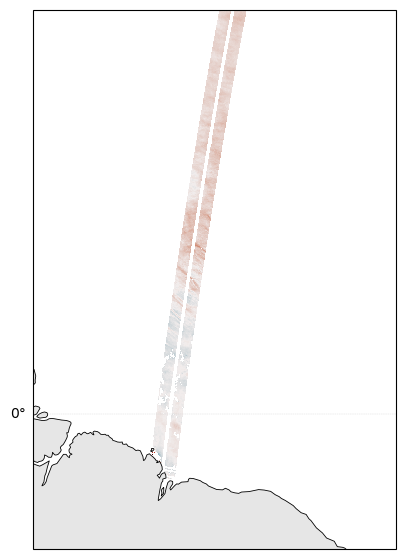

In [13]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import cmocean
fig,ax = plt.subplots(figsize=(14,7),subplot_kw={'projection':ccrs.Robinson()})
ax.set_global()
ax.add_feature(cfeature.LAND,facecolor="0.9",edgecolor="none")
ax.add_feature(cfeature.COASTLINE,linewidth=0.6)
ax.add_feature(cfeature.BORDERS,linewidth=0.3)
gl = ax.gridlines(draw_labels=True,linewidth=0.3,linestyle="--",alpha=0.5)
    
gl.top_labels = False
gl.right_labels = False

gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))

gl.xlabel_style = {"size": 10,"color": "black",}

gl.ylabel_style = {"size": 10,"color": "black",}

sc = ax.pcolormesh(data_expert['longitude'], data_expert['latitude'], data_expert['ssha'], transform=ccrs.PlateCarree(),
                   cmap=cmocean.cm.balance, vmin = -1, vmax=1)
#ax.scatter(-40,10, transform=ccrs.PlateCarree())
ax.set_extent([-50,-35,-5,15], crs=ccrs.PlateCarree()) #Amazon
#ax.set_extent([40,75,-22,8], crs=ccrs.PlateCarree()) # Mascarene
plt.show()

## 3.1D- along-track spectra

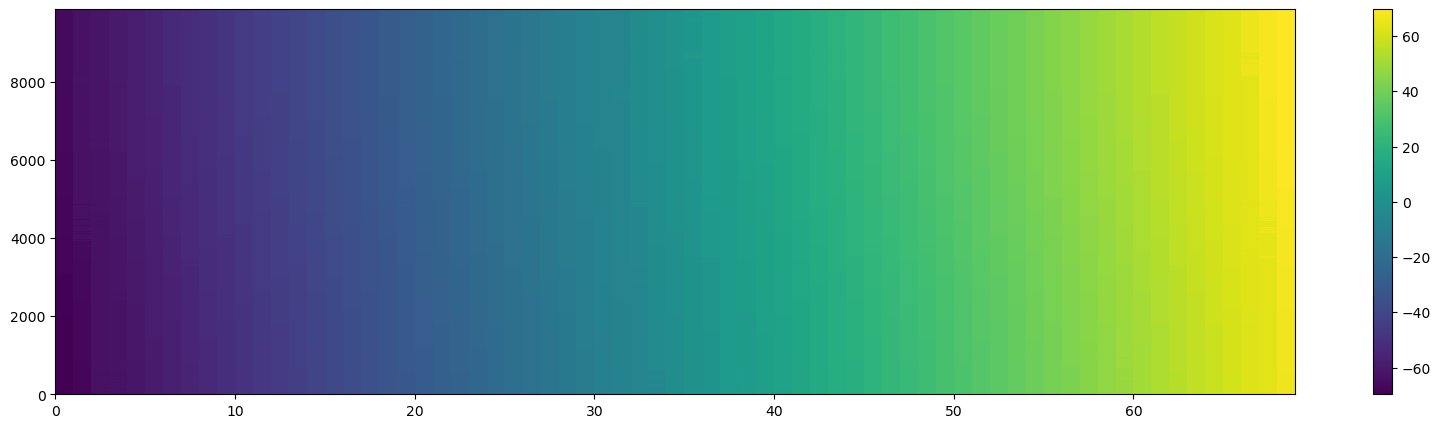

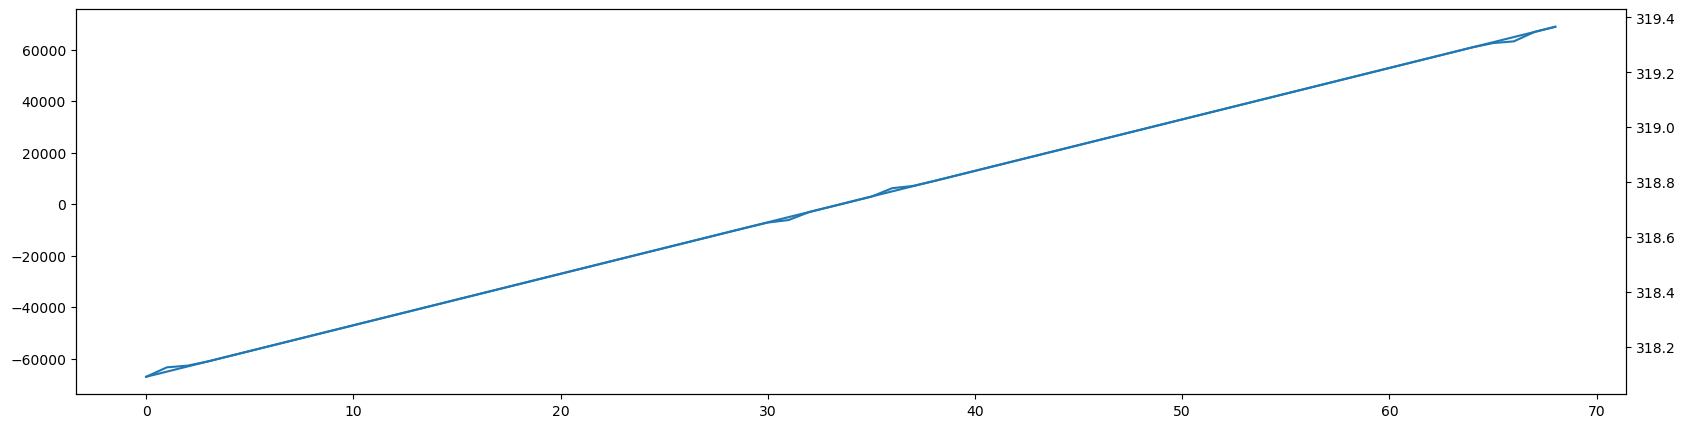

In [14]:
plt.figure(figsize=(20,5))
cs = plt.pcolormesh(data_expert['cross_track_distance']*1e-3)
plt.colorbar(cs)
np.nanmedian(data_expert['cross_track_distance'])

plt.figure(figsize=(20,5))
plt.plot(data_expert['cross_track_distance'][6000,:])
plt.twinx()
plt.plot(data_expert['longitude'][6000,:])

## 4. Diagnostics- comparison

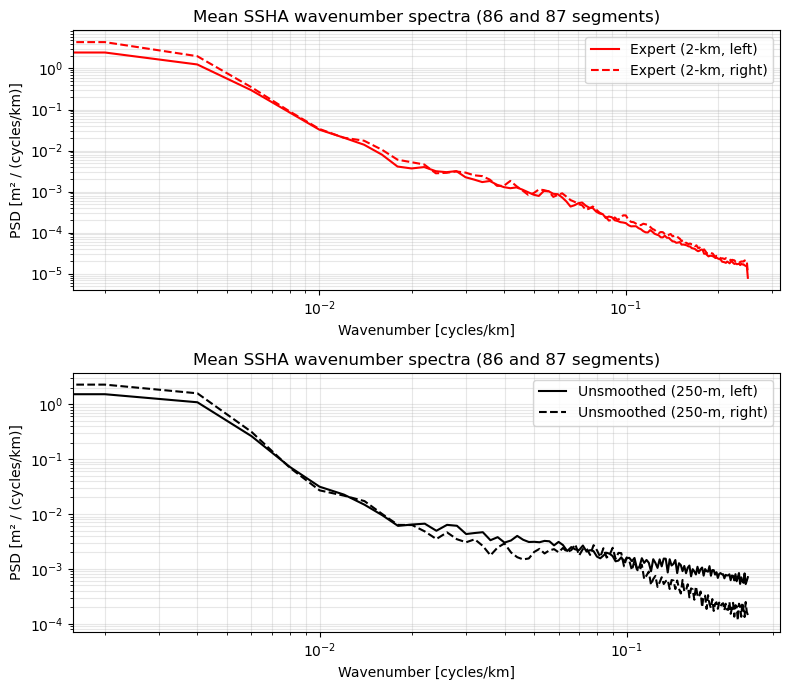

In [15]:
fig, axs = plt.subplots(2,1,figsize=(8,7))
ax = axs[0]
ds_segments_expert.where(ds_segments_expert.swath=='left',drop=True
                        ).mean('segment').psd.plot(ax=ax,xscale='log',yscale='log', c = "r", label = "Expert (2-km, left)")
ds_segments_expert.where(ds_segments_expert.swath=='right',drop=True
                        ).mean('segment').psd.plot(ax=ax,xscale='log',yscale='log', c = "r", ls = "--", label = "Expert (2-km, right)")
ax = axs[1]
ds_segments_unsmoothed.where(ds_segments_unsmoothed.swath=='left',drop=True
                        ).mean('segment').total_psd.plot(ax=ax,xscale='log',yscale='log', c = "k", label = "Unsmoothed (250-m, left)")
ds_segments_unsmoothed.where(ds_segments_unsmoothed.swath=='right',drop=True
                        ).mean('segment').total_psd.plot(ax=ax,xscale='log',yscale='log', c = "k", ls = "--", label = "Unsmoothed (250-m, right)")

for ax in axs:
    ax.grid();
    ax.set_xlabel("Wavenumber [cycles/km]")
    ax.set_ylabel("PSD [m² / (cycles/km)]")
    ax.set_title(f"Mean SSHA wavenumber spectra ({ds_segments_expert.segment.size} and {ds_segments_unsmoothed.segment.size} segments)")
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

Text(0.5, 1.0, 'Unsmoothed (250m)')

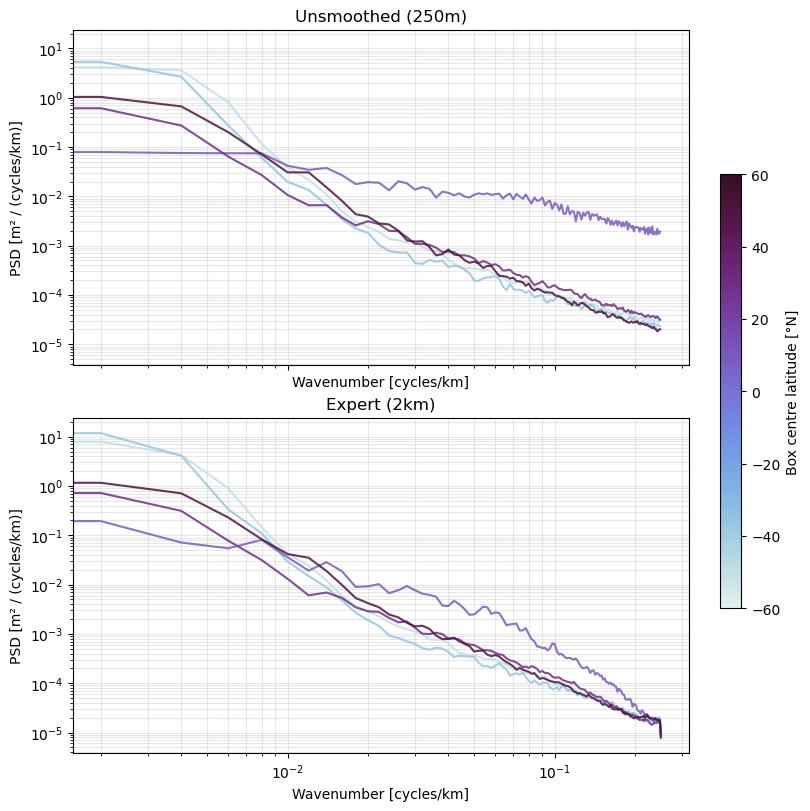

In [16]:
import cmocean
LAT_BIN_EDGES = np.arange(-60, 61, 20)  # adjust to the pass's latitude range
binned_spectra = [ds_segments_unsmoothed.groupby_bins("lat_mean", LAT_BIN_EDGES).mean(),
                  ds_segments_expert.groupby_bins("lat_mean", LAT_BIN_EDGES).mean(),
                  ]

fig, axs = plt.subplots(2,1,figsize=(8, 8),sharex=True, sharey=True, constrained_layout=True)
lat_vals = binned_spectra[0]["lat_mean_bins"].values
norm = plt.Normalize(vmin=np.min(LAT_BIN_EDGES), vmax=np.max(LAT_BIN_EDGES))
cmap = plt.get_cmap(cmocean.cm.dense)

for i in range(binned_spectra[0].sizes["lat_mean_bins"]):
    lat_box_un = binned_spectra[0].isel(lat_mean_bins = i)
    lat_box_ex = binned_spectra[1].isel(lat_mean_bins = i)
    axs[0].loglog(lat_box_un["wavenumber"], lat_box_un["total_psd"],color=cmap(norm(float(lat_box_un["lat_mean"]))),lw=1.5, alpha=0.85)
    axs[1].loglog(lat_box_ex["wavenumber"], lat_box_ex["psd"],color=cmap(norm(float(lat_box_ex["lat_mean"]))),lw=1.5, alpha=0.85)
axs[0].set_xlabel('')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=axs, label="Box centre latitude [°N]",shrink=0.6)
for ax in axs: 
    ax.set_xlabel("Wavenumber [cycles/km]")
    ax.set_ylabel("PSD [m² / (cycles/km)]")
    ax.grid(True, which="both", alpha=0.3)
#fig.tight_layout()
axs[1].set_title("Expert (2km)")
axs[0].set_title("Unsmoothed (250m)")

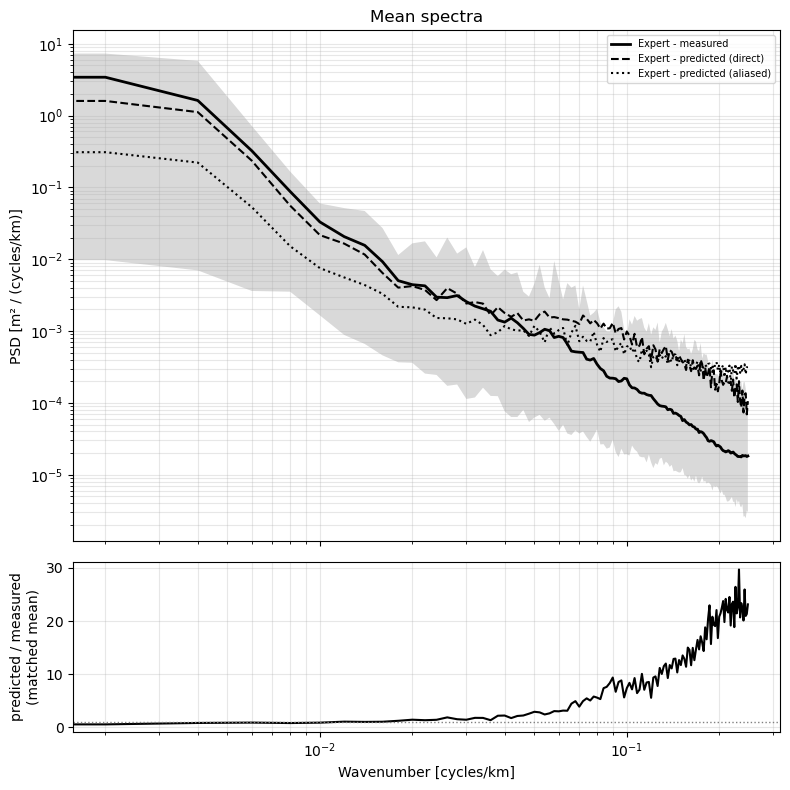

In [17]:
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1]))
c = 'k'
k = ds_segments_unsmoothed['wavenumber']
direct_median = ds_segments_unsmoothed.direct_psd.mean('segment')#np.nanmean(direct_stack, axis=0)
direct_lo, direct_hi = np.nanpercentile(ds_segments_unsmoothed.direct_psd, [5, 95], axis=0)
aliased_median = ds_segments_unsmoothed.aliased_psd.mean('segment')
aliased_lo, aliased_hi = np.nanpercentile(ds_segments_unsmoothed.aliased_psd, [25, 75], axis=0)
meas_median = ds_segments_expert.psd.mean('segment')
total_median = ds_segments_unsmoothed.total_psd.mean('segment')

ax = axs[0]
ax.fill_between(k, direct_lo, direct_hi, color=c, alpha=0.15, lw=0)
try:
    ax.loglog(k, meas_median[:], c=c, lw=2, label=f'Expert - measured ')
    axs[1].semilogx(k, total_median.values / meas_median.values[:], c=c, lw=1.5)
except:
    ax.loglog(k, meas_median[:-1], c=c, lw=2, label=f'Expert - measured ')
    axs[1].semilogx(k, total_median.values / meas_median.values[:-1], c=c, lw=1.5)
    
ax.loglog(k, direct_median, c=c, lw=1.5, ls='--', label=f'Expert - predicted (direct)')
ax.loglog(k, aliased_median, c=c, lw=1.5, ls=':', label=f'Expert - predicted (aliased)')


axs[0].set_ylabel('PSD [m² / (cycles/km)]')
axs[0].set_title(f'Mean spectra')
axs[0].grid(True, which='both', alpha=0.3)
axs[0].legend(fontsize=7)

axs[1].axhline(1.0, c='0.5', ls=':', lw=1)
axs[1].set_ylabel('predicted / measured\n(matched mean)')
axs[1].set_xlabel('Wavenumber [cycles/km]')
axs[1].grid(True, which='both', alpha=0.3)
#axs[1].legend(fontsize=8)
fig.tight_layout()

In [18]:
# Flagging
recs_01   = ds_segments_unsmoothed.sel(wavenumber=0.1,method='nearest')
flagged   = ds_segments_unsmoothed.where(recs_01.total_psd<=1e-3)
flagged = flagged.where((flagged.lat_mean<=LAT_MAX) & (flagged.lat_mean>=LAT_MIN))

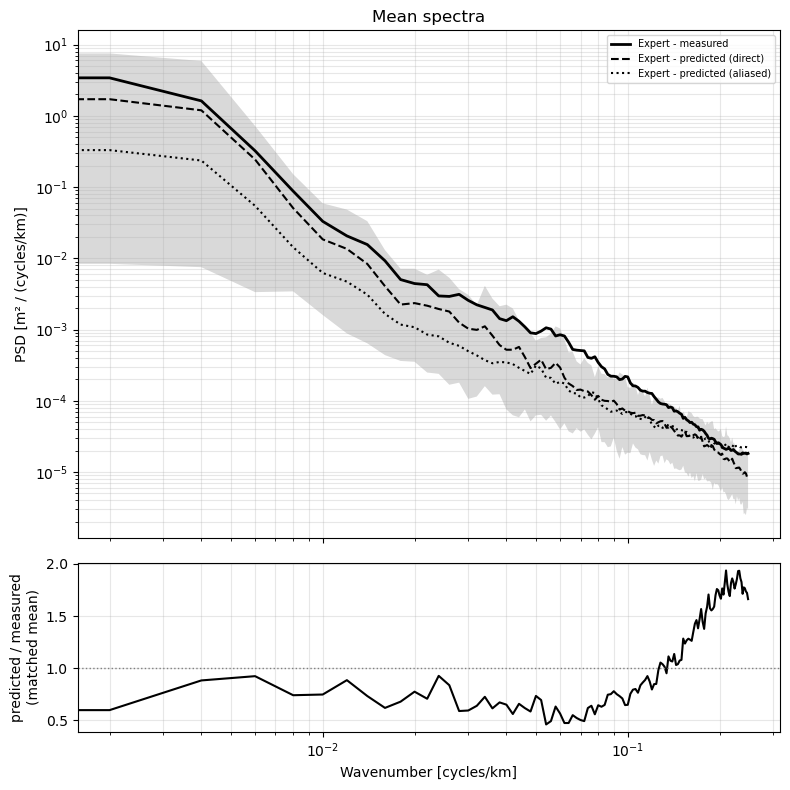

In [19]:
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1]))
c = 'k'
k = flagged['wavenumber']
direct_median = flagged.direct_psd.mean('segment')#np.nanmean(direct_stack, axis=0)
direct_lo, direct_hi = np.nanpercentile(flagged.direct_psd, [5, 95], axis=0)
aliased_median = flagged.aliased_psd.mean('segment')
aliased_lo, aliased_hi = np.nanpercentile(flagged.aliased_psd, [25, 75], axis=0)
meas_median = ds_segments_expert.psd.mean('segment')
total_median = flagged.total_psd.mean('segment')

ax = axs[0]
ax.fill_between(k, direct_lo, direct_hi, color=c, alpha=0.15, lw=0)
try:
    ax.loglog(k, meas_median[:], c=c, lw=2, label=f'Expert - measured ')
    axs[1].semilogx(k, total_median.values / meas_median.values[:], c=c, lw=1.5)
except:
    ax.loglog(k, meas_median[:-1], c=c, lw=2, label=f'Expert - measured ')
    axs[1].semilogx(k, total_median.values / meas_median.values[:-1], c=c, lw=1.5)
ax.loglog(k, direct_median, c=c, lw=1.5, ls='--', label=f'Expert - predicted (direct)')
ax.loglog(k, aliased_median, c=c, lw=1.5, ls=':', label=f'Expert - predicted (aliased)')


axs[0].set_ylabel('PSD [m² / (cycles/km)]')
axs[0].set_title(f'Mean spectra')
axs[0].grid(True, which='both', alpha=0.3)
axs[0].legend(fontsize=7)

axs[1].axhline(1.0, c='0.5', ls=':', lw=1)
axs[1].set_ylabel('predicted / measured\n(matched mean)')
axs[1].set_xlabel('Wavenumber [cycles/km]')
axs[1].grid(True, which='both', alpha=0.3)
#axs[1].legend(fontsize=8)
fig.tight_layout()

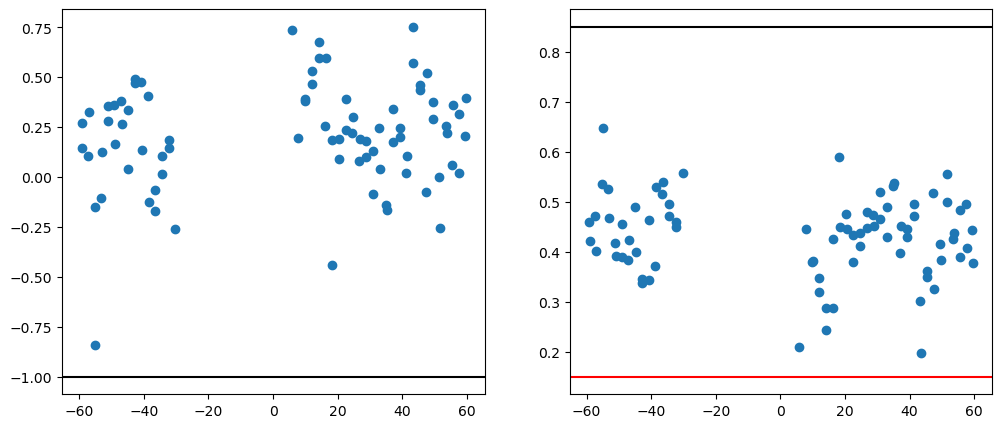

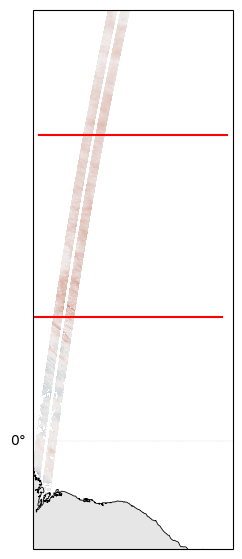

In [20]:
kmin,kmax=1/30,1/10
fig, axs = plt.subplots(1,2,figsize=(12,5))
_ds = flagged.sel(wavenumber=slice(kmin,kmax))
axs[0].scatter(_ds.lat_mean,(_ds.direct_psd.integrate('wavenumber')-_ds.aliased_psd.integrate('wavenumber')) / _ds.direct_psd.integrate('wavenumber'))
axs[1].scatter(_ds.lat_mean,(_ds.aliased_psd.integrate('wavenumber')) / _ds.total_psd.integrate('wavenumber'))
axs[0].axhline(-1.0,c='k')
axs[1].axhline(0.15,c='r')
axs[1].axhline(0.85,c='k')

lat_aliased = [l for l in _ds.where((_ds.direct_psd.integrate('wavenumber')-_ds.aliased_psd.integrate('wavenumber')
                                    ) / _ds.direct_psd.integrate('wavenumber') <-1.0, drop=True
                                   ).lat_mean.values]
lat_direct = [l for l in _ds.where((_ds.aliased_psd.integrate('wavenumber')
                                    ) / _ds.total_psd.integrate('wavenumber') <0.25, drop=True
                                   ).lat_mean.values]

#lat_aliased = [l for l in _ds.where((_ds.aliased_psd.integrate('wavenumber')
#                                    ) / _ds.total_psd.integrate('wavenumber') > 0.85, drop=True
#                                   ).lat_mean.values]

fig,ax = plt.subplots(figsize=(14,7),subplot_kw={'projection':ccrs.Robinson()})
ax.set_global()
ax.add_feature(cfeature.LAND,facecolor="0.9",edgecolor="none")
ax.add_feature(cfeature.COASTLINE,linewidth=0.6)
ax.add_feature(cfeature.BORDERS,linewidth=0.3)
gl = ax.gridlines(draw_labels=True,linewidth=0.3,linestyle="--",alpha=0.5)
    
gl.top_labels = False
gl.right_labels = False

gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))

gl.xlabel_style = {"size": 10,"color": "black",}

gl.ylabel_style = {"size": 10,"color": "black",}

sc = ax.pcolormesh(data_expert['longitude'], data_expert['latitude'], data_expert['ssha'], transform=ccrs.PlateCarree(),
                   cmap=cmocean.cm.balance, vmin = -1, vmax=1)

for l in lat_aliased:
    #ax.plot([60,65], [l,l], transform=ccrs.PlateCarree(),c='k') #Mascarene SE
    #ax.plot([45,55], [l,l], transform=ccrs.PlateCarree(),c='k') #Mascarene NW
    ax.plot([-50,-30], [l,l], transform=ccrs.PlateCarree(),c='k') #Amazon
for l in lat_direct:
    #ax.plot([60,65], [l,l], transform=ccrs.PlateCarree(),c='r') #Mascarene SE
    #ax.plot([45,55], [l,l], transform=ccrs.PlateCarree(),c='r') #Mascarene NW
    ax.plot([-45,-35], [l,l], transform=ccrs.PlateCarree(),c='r') #Amazon

#ax.set_extent([61,64,-22,-10], crs=ccrs.PlateCarree())  #Mascarene SE
#ax.set_extent([45,55,-22,10], crs=ccrs.PlateCarree())  #Mascarene NW
ax.set_extent([-45,-35,-5,20], crs=ccrs.PlateCarree())   #Amazon

plt.show()


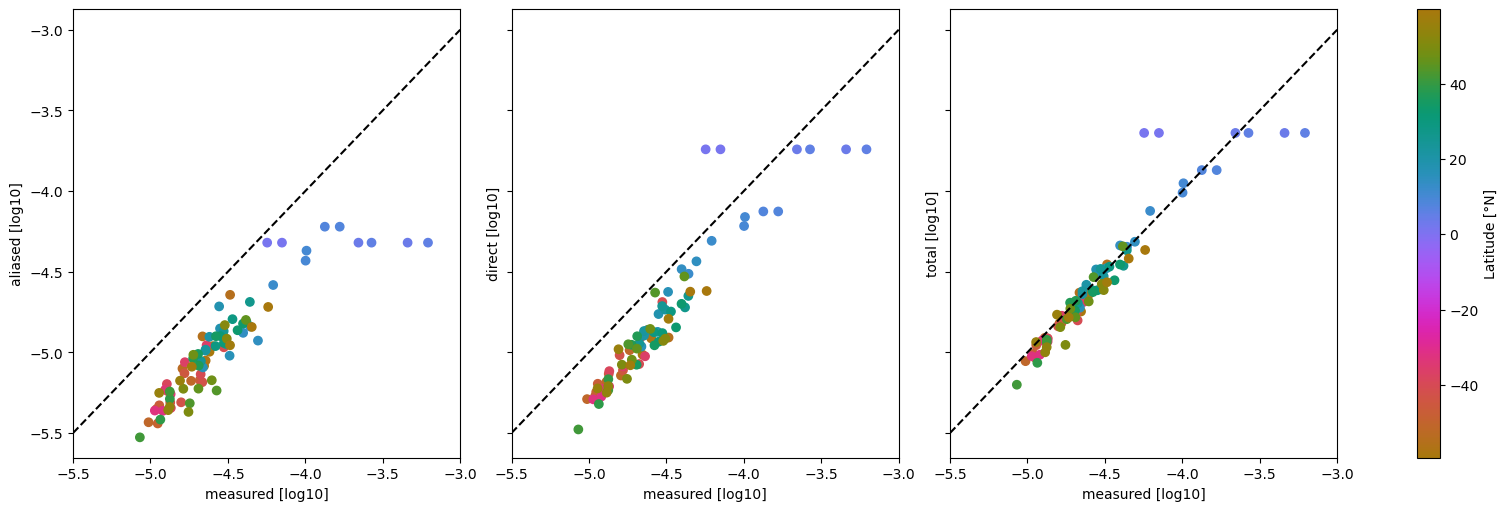

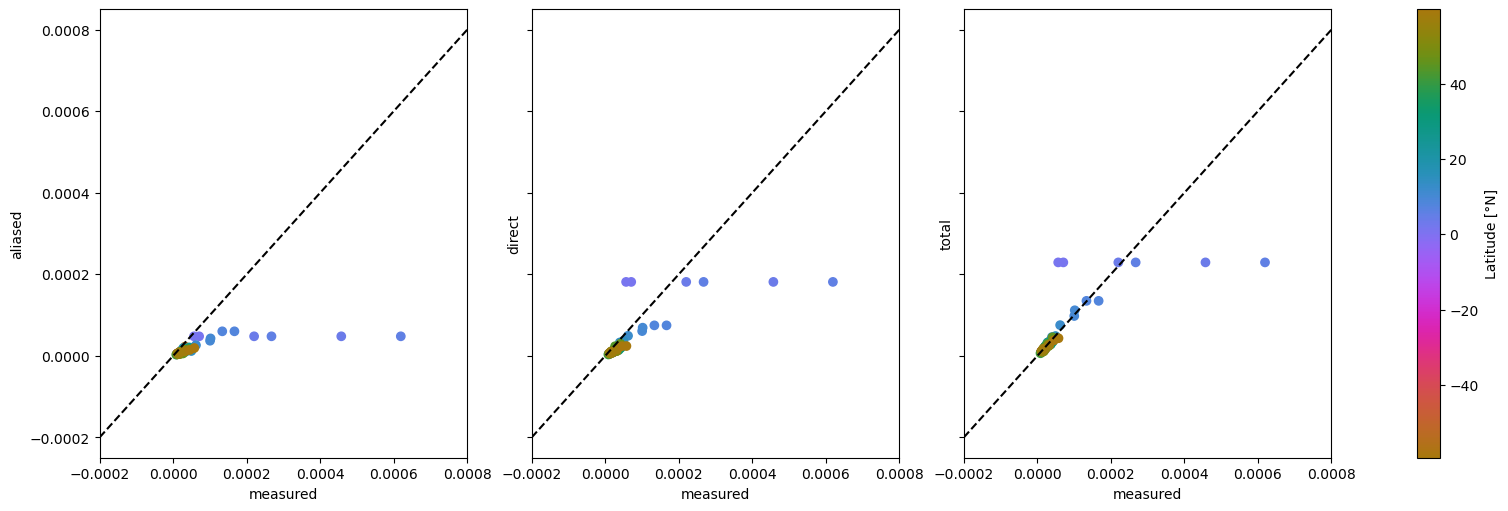

In [21]:

_ds = flagged.sel(wavenumber=slice(kmin,kmax))
_ds_ex = ds_segments_expert.sel(wavenumber=slice(kmin,kmax))
_ds = _ds.sortby('lat_mean').dropna('segment')
_ds_ex = _ds_ex.sortby('lat_mean')
_ds = _ds.assign_coords({'segment':_ds.lat_mean})
lat_ex = _ds_ex.lat_mean

fig, axs = plt.subplots(1,3,figsize=(15,5),sharey=True, sharex=True, constrained_layout=True)
ax=axs[0]
sc = ax.scatter(np.log10(_ds_ex.psd.integrate('wavenumber')),
                np.log10(_ds.sel(segment=lat_ex, method='nearest').aliased_psd.integrate('wavenumber')),
           c=lat_ex,cmap=cmocean.cm.phase)
ax.set_ylabel('aliased [log10]')
axs[1].scatter(np.log10(_ds_ex.psd.integrate('wavenumber')),
                np.log10(_ds.sel(segment=lat_ex, method='nearest').direct_psd.integrate('wavenumber')),
           c=lat_ex,cmap=cmocean.cm.phase)
axs[1].set_ylabel('direct [log10]')
axs[2].scatter(np.log10(_ds_ex.psd.integrate('wavenumber')),
                np.log10(_ds.sel(segment=lat_ex, method='nearest').total_psd.integrate('wavenumber')),
           c=lat_ex,cmap=cmocean.cm.phase)
axs[2].set_ylabel('total [log10]')
plt.colorbar(sc,ax=axs,label='Latitude [°N]')
axs[0].set_xlim(np.log10(_ds_ex.psd.integrate('wavenumber')).min(), np.log10(_ds_ex.psd.integrate('wavenumber')).max())
x = axs[0].get_xticks()[:]
for ax in axs:
    ax.set_xlabel('measured [log10]')
    ax.plot(x[:],x[:],c='k',ls='--')
    ax.set_xlim(x[0],x[-1])
#plt.axhline(1,c='k')

fig, axs = plt.subplots(1,3,figsize=(15,5),sharey=True, sharex=True, constrained_layout=True)
ax=axs[0]
sc = ax.scatter(_ds_ex.psd.integrate('wavenumber'),
                _ds.sel(segment=lat_ex, method='nearest').aliased_psd.integrate('wavenumber'),
           c=lat_ex,cmap=cmocean.cm.phase)
ax.set_ylabel('aliased')
axs[1].scatter(_ds_ex.psd.integrate('wavenumber'),
                _ds.sel(segment=lat_ex, method='nearest').direct_psd.integrate('wavenumber'),
           c=lat_ex,cmap=cmocean.cm.phase)
axs[1].set_ylabel('direct')
axs[2].scatter(_ds_ex.psd.integrate('wavenumber'),
            _ds.sel(segment=lat_ex, method='nearest').total_psd.integrate('wavenumber'),
           c=lat_ex,cmap=cmocean.cm.phase)
axs[2].set_ylabel('total')
plt.colorbar(sc,ax=axs,label='Latitude [°N]')
#axs[0].set_xlim(_ds_ex.psd.integrate('wavenumber').min(), _ds_ex.psd.integrate('wavenumber')).max()
x = axs[0].get_xticks()[:]
for ax in axs:
    ax.set_xlabel('measured')
    ax.plot(x[:],x[:],c='k',ls='--')
    ax.set_xlim(x[0],x[-1])
#plt.axhline(1,c='k')

Text(0.5, 1.0, 'Direct, Expert')

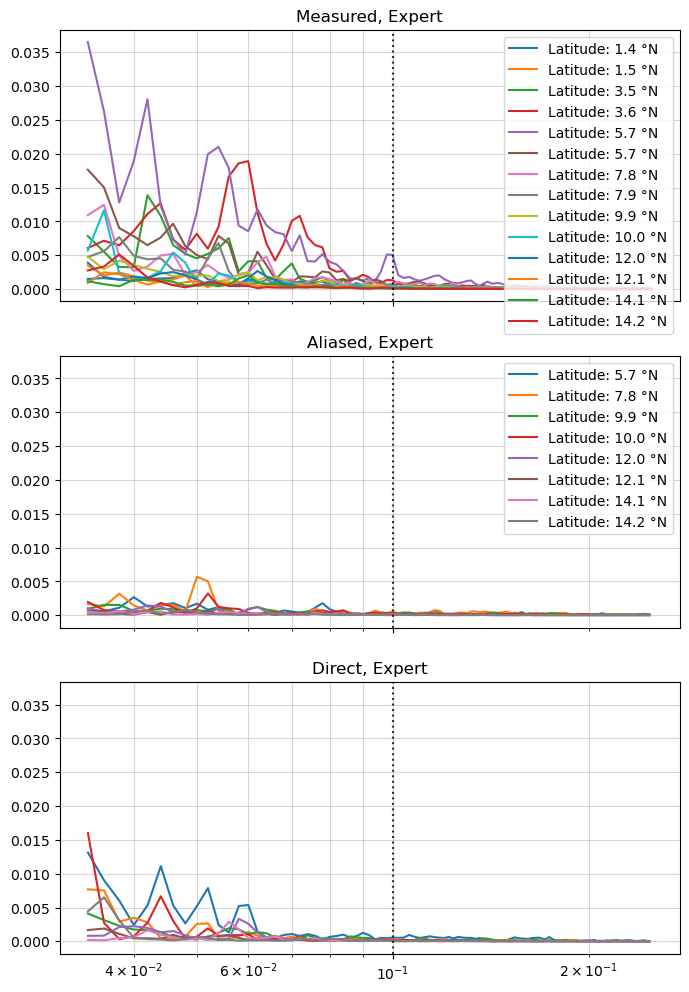

In [22]:
latitudes = np.sort(flagged.lat_mean.dropna('segment'))#np.arange(flagged.lat_mean.min(),flagged.lat_mean.max(),2)
latitudes_ex = np.sort(ds_segments_expert.lat_mean)
lmin, lmax= -5,15
cmap = plt.get_cmap(cmocean.cm.dense_r)
norm = plt.Normalize(vmin=-5, vmax=15)

fig, axs = plt.subplots(3,1,figsize=(8,12),sharey=True,sharex=True
                       )
for i,l in enumerate(np.sort(flagged.lat_mean.dropna('segment'))):
    if flagged.aliased_psd.where(flagged.lat_mean==l,drop=True).size==0:
        pass
    else:
        if l>=lmin and l<=lmax:
            _ = flagged.where(flagged.lat_mean==l,drop=True).sel(wavenumber=slice(1/30,None))
            #_ex = ds_segments_expert.where(ds_segments_expert.lat_mean==l,drop=True).sel(wavenumber=slice(1/30,None))
            #axs[0].semilogx(_.wavenumber,(_ex.psd)[0,:], c=cmap(norm(i)),label=f'Latitude: {l:.1f} °N')
            axs[1].semilogx(_.wavenumber,(_.aliased_psd)[0,:],label=f'Latitude: {l:.1f} °N')
            axs[2].semilogx(_.wavenumber,(_.direct_psd)[0,:])
axs[1].legend(loc=1)
for i,l in enumerate(np.sort(ds_segments_expert.lat_mean)):
    if l>=lmin and l<=lmax:
        _ex = ds_segments_expert.where(ds_segments_expert.lat_mean==l,drop=True).sel(wavenumber=slice(1/30,None))
        axs[0].semilogx(_ex.wavenumber,(_ex.psd)[0,:],label=f'Latitude: {l:.1f} °N') # c=cmap(norm(i)),
for ax in axs:
    ax.grid(True,which='both',alpha=0.5)
    #ax.axvline(1/30,ls=':',c='k',alpha=0.8)
    #ax.axvline(1/50,ls=':',c='k',alpha=0.8)
    ax.axvline(1/10,ls=':',c='k',alpha=0.8)
axs[0].legend(loc=1)
axs[0].set_title('Measured, Expert');
axs[1].set_title('Aliased, Expert');
axs[2].set_title('Direct, Expert')

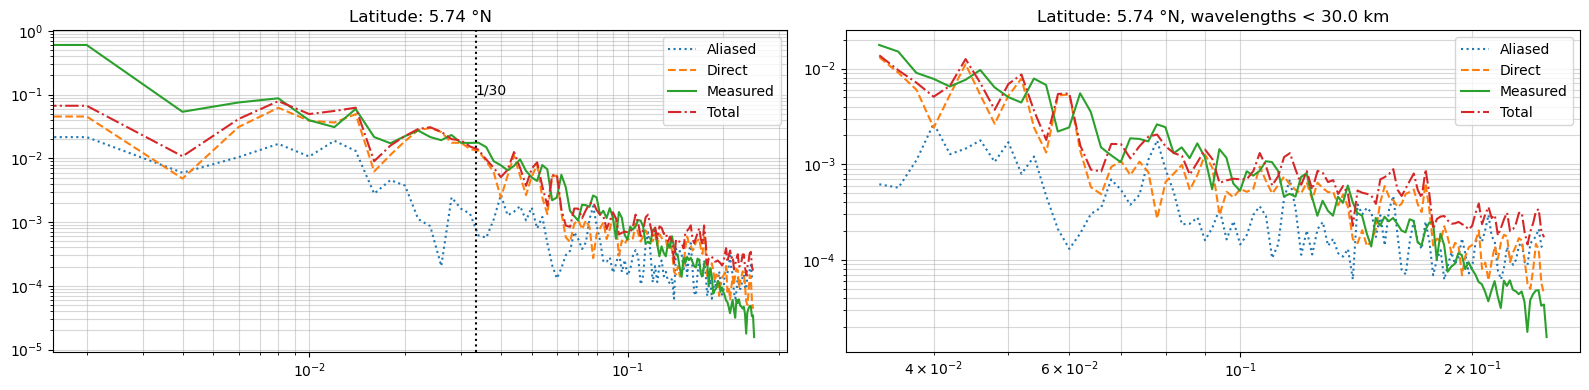

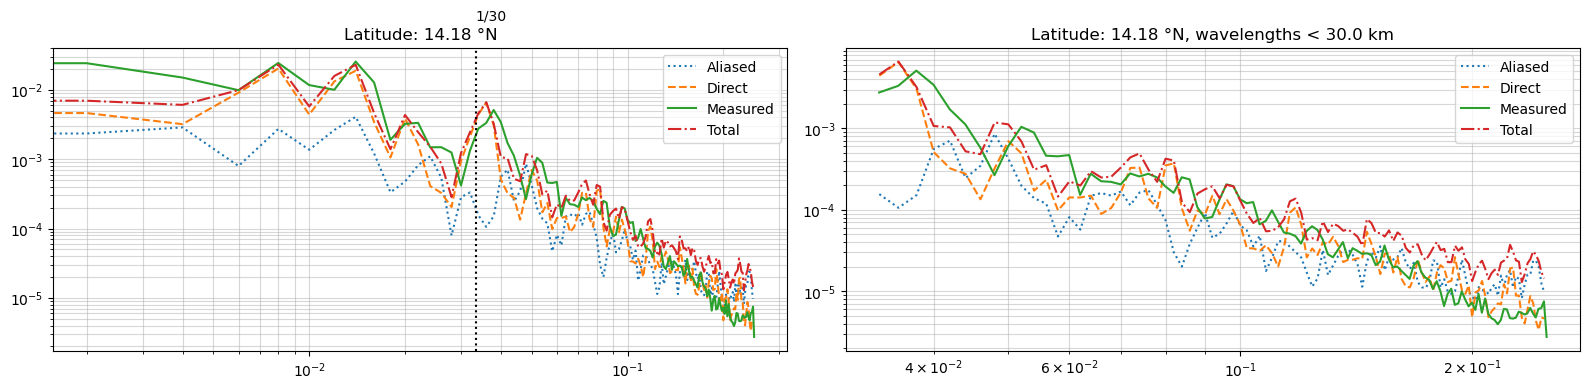

In [23]:
dlat = 0.01
for l in lat_aliased:
    if l>=lmin and l<=lmax:
        ds_lat = flagged.where(flagged.lat_mean==l,drop=True)
        ds_lat_ex = ds_segments_expert.where((_ds_ex.lat_mean<=l+dlat) & (_ds_ex.lat_mean>=l-dlat),drop=True)
        fig, axs = plt.subplots(1,2,figsize=(16,4),sharey=False)
        ax=axs[0]
        ax.loglog(ds_lat.wavenumber, ds_lat.aliased_psd[0,:],ls=':',label='Aliased')
        ax.loglog(ds_lat.wavenumber, ds_lat.direct_psd[0,:],ls='--',label='Direct')
        ax.loglog(ds_lat_ex.wavenumber, ds_lat_ex.psd[0,:],ls='-',label='Measured')
        ax.loglog(ds_lat.wavenumber, ds_lat.total_psd[0,:],ls='-.',label='Total')
        ax.axvline(1/30,ls=':',c='k');
        ax.text(1/30,1e-1,'1/30')
        ax=axs[1]
        ax.loglog(ds_lat.sel(wavenumber=slice(kmin,None)).wavenumber, ds_lat.sel(wavenumber=slice(kmin,None)).aliased_psd[0,:]
                  ,ls=':',label='Aliased')
        ax.loglog(ds_lat.sel(wavenumber=slice(kmin,None)).wavenumber, ds_lat.sel(wavenumber=slice(kmin,None)).direct_psd[0,:]
                  ,ls='--',label='Direct')
        ax.loglog(ds_lat_ex.sel(wavenumber=slice(kmin,None)).wavenumber, ds_lat_ex.sel(wavenumber=slice(kmin,None)).psd[0,:]
                  ,ls='-',label='Measured')
        ax.loglog(ds_lat.sel(wavenumber=slice(kmin,None)).wavenumber, ds_lat.sel(wavenumber=slice(kmin,None)).total_psd[0,:]
                  ,ls='-.',label='Total')
        for ax in axs:
            ax.legend();ax.grid(True,which='both',alpha=0.5)
            ax.set_title(f'Latitude: {l:.2f} °N');
        fig.tight_layout()

for l in lat_direct:
    if l>=lmin and l<=lmax:
        ds_lat = flagged.where(flagged.lat_mean==l,drop=True)
        ds_lat_ex = ds_segments_expert.where((_ds_ex.lat_mean<=l+dlat) & (_ds_ex.lat_mean>=l-dlat),drop=True)
        fig, axs = plt.subplots(1,2,figsize=(16,4),sharey=False)
        ax=axs[0]
        ax.loglog(ds_lat.wavenumber, ds_lat.aliased_psd[0,:],ls=':',label='Aliased')
        ax.loglog(ds_lat.wavenumber, ds_lat.direct_psd[0,:],ls='--',label='Direct')
        ax.loglog(ds_lat_ex.wavenumber, ds_lat_ex.psd[0,:],ls='-',label='Measured')
        ax.loglog(ds_lat.wavenumber, ds_lat.total_psd[0,:],ls='-.',label='Total')
        ax.axvline(1/30,ls=':',c='k');
        ax.text(1/30,1e-1,'1/30')
        ax=axs[1]
        ax.loglog(ds_lat.sel(wavenumber=slice(kmin,None)).wavenumber, ds_lat.sel(wavenumber=slice(kmin,None)).aliased_psd[0,:]
                  ,ls=':',label='Aliased')
        ax.loglog(ds_lat.sel(wavenumber=slice(kmin,None)).wavenumber, ds_lat.sel(wavenumber=slice(kmin,None)).direct_psd[0,:]
                  ,ls='--',label='Direct')
        ax.loglog(ds_lat_ex.sel(wavenumber=slice(kmin,None)).wavenumber, ds_lat_ex.sel(wavenumber=slice(kmin,None)).psd[0,:]
                  ,ls='-',label='Measured')
        ax.loglog(ds_lat.sel(wavenumber=slice(kmin,None)).wavenumber, ds_lat.sel(wavenumber=slice(kmin,None)).total_psd[0,:]
                  ,ls='-.',label='Total')
        for ax in axs:
            ax.legend();ax.grid(True,which='both',alpha=0.5)
        axs[1].set_title(f'Latitude: {l:.2f} °N, wavelengths < {1/kmin:.1f} km');
        axs[0].set_title(f'Latitude: {l:.2f} °N');
        fig.tight_layout()